# Team 3 — Milestone 3: ED Wait Time Prediction - ML Pipeline

**Course:** CSCI-7090 — Data Science and Machine Learning
**Institution:** Georgia Southern University
**Team:** Vandan Patel, Annagrace Howell, Yasmin Rocio Orduz Landazabal
**Intructor:** Ph.D. Vijayalakshmi Ramasamy
**Semester:** Spring 2026

---

## What this notebook does

This notebook is the **final ML pipeline** for our Emergency Department (ED)
Wait Time Prediction project. It loads the cleaned dataset produced in
Milestone 2, trains and benchmarks five regression models, applies SHAP-based
interpretability, evaluates per-ESI-level performance, and audits demographic
fairness across race/ethnicity, gender, and age group.

Every numerical result reported in our final paper
(`Team3_Final_Paper.pdf`) is reproduced by running the `main()` cell at the
bottom of this notebook.

## Notebook structure

1. **Setup** — imports, constants, reproducibility.
2. **Data loading** — load the cleaned CSV from Milestone 2.
3. **Feature engineering check** — confirm the 19-feature regression vector.
4. **Modeling** — five regression models, 80/20 split, 5-fold CV.
5. **Interpretability** — SHAP TreeExplainer on LightGBM.
6. **Stratified evaluation** — per-ESI-level Ridge performance.
7. **Fairness audit** — MAE/RMSE by race/ethnicity, gender, age group.
8. **`main()`** — runs everything end-to-end and prints the full result tables.

## Data source

The cleaned CSV (`team3_ed_waittime_cleaned.csv`) is produced by
`Team3_Milestone2_ED_WaitTime.ipynb` and is also published in our GitHub repo:

> https://github.com/Yasmin-maker1/Emergency-Department-Wait-Time-Prediction-Using-Machine-Learning

## 1. Setup

We import the standard scientific stack plus three model-specific libraries
(`xgboost`, `lightgbm`, `shap`) and fix a single random seed so every result
in this notebook is exactly reproducible.

If a library is missing in your environment, uncomment the `pip install` line.

In [1]:
# !pip install -q xgboost lightgbm shap scikit-learn pandas matplotlib seaborn

import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import shap

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

RANDOM_STATE = 42
# Data source: cleaned CSV published in our GitHub repo (Run All works without upload).
DATA_PATH = "https://raw.githubusercontent.com/Yasmin-maker1/Emergency-Department-Wait-Time-Prediction-Using-Machine-Learning/main/team3_ed_waittime_cleaned.csv"

print("Setup complete.")

Setup complete.


## 2. Data Loading

`team3_ed_waittime_cleaned.csv` is the output of Milestone 2: 9,216 ED
visits, 26 columns (17 original + 9 engineered), zero missing values.

Below we load it, peek at the first rows, and confirm the row count and
columns.

In [2]:
def load_data(path: str = DATA_PATH) -> pd.DataFrame:
    """Load the cleaned ED dataset.

    DATA_PATH (set in the Setup cell) points to the cleaned CSV in our GitHub
    repository, so this notebook runs end-to-end in Colab without any manual
    upload step. The function also accepts a local file path if you prefer to
    work offline.
    """
    import os
    # If DATA_PATH is a URL, pandas will fetch it directly.
    # If it's a local path, we check existence first for a clearer error message.
    if path.startswith("http"):
        return pd.read_csv(path)
    if os.path.exists(path):
        return pd.read_csv(path)
    raise FileNotFoundError(
        f"Could not find CSV at: {path}\n"
        "Either upload team3_ed_waittime_cleaned.csv to your Colab session, "
        "or set DATA_PATH to the GitHub raw URL of the file."
    )

df = load_data()
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset shape: (9216, 26)
Columns: ['age', 'heartrate', 'sbp', 'dbp', 'temperature', 'o2sat', 'resprate', 'pain_score', 'acuity', 'shock_index', 'pulse_pressure', 'arrival_hour', 'is_weekend', 'was_admitted', 'gender_encoded', 'race_encoded', 'arrival_transport_encoded', 'arrival_shift_encoded', 'age_group_encoded', 'ed_los_minutes', 'gender', 'race', 'arrival_transport', 'disposition', 'arrival_shift', 'age_group']


,age,heartrate,sbp,dbp,temperature,o2sat,resprate,pain_score,acuity,shock_index,...,arrival_transport_encoded,arrival_shift_encoded,age_group_encoded,ed_los_minutes,gender,race,arrival_transport,disposition,arrival_shift,age_group
0,44,102.265147,141.095945,70.307029,98.965459,98.537410,18.200397,8.0,3,0.724792,...,3,2,1,304.098208,F,WHITE,WALK IN,HOME,Night,Middle Age
1,59,67.356904,104.774481,106.588915,98.406250,97.532219,19.635054,2.0,5,0.642875,...,3,1,1,78.614146,F,BLACK/AFRICAN AMERICAN,WALK IN,HOME,Evening,Middle Age
2,30,85.669901,139.438382,76.728783,100.496952,99.262800,19.417147,0.0,4,0.614393,...,3,2,3,133.926134,M,HISPANIC,WALK IN,HOME,Night,Young Adult
3,13,87.231441,144.605492,82.802628,97.977442,96.686435,16.864104,4.0,4,0.603237,...,1,0,2,72.742728,M,WHITE,OTHER,HOME,Day,Pediatric
4,27,78.015246,164.890910,71.840335,100.372138,99.738310,17.418224,7.0,3,0.473132,...,0,2,3,64.222496,F,WHITE,AMBULANCE,ADMITTED,Night,Young Adult


**Observation.** Dataset is 9,216 rows × 26 columns, exactly as expected
from Milestone 2. The target column is `ed_los_minutes` (continuous, in
minutes); all 25 other columns are candidate predictors or auxiliary
metadata for the fairness audit (raw `race`, `gender`, `age_group` strings).

## 3. Feature Set

The regression input vector contains 19 standardized features, grouped by
clinical role:

- **Demographics:** `age`, `gender_encoded`, `race_encoded`, `age_group_encoded`
- **Vital signs:** `heartrate`, `sbp`, `dbp`, `temperature`, `o2sat`, `resprate`
- **Triage:** `acuity` (ESI 1–5), `pain_score`
- **Engineered physiology:** `shock_index`, `pulse_pressure`
- **Arrival context:** `arrival_hour`, `is_weekend`, `arrival_transport_encoded`,
  `arrival_shift_encoded`
- **Disposition:** `was_admitted`

The seven remaining columns (raw categorical strings + the target) are
excluded from training but kept for the fairness audit later.

In [3]:
FEATURES = [
    "age", "heartrate", "sbp", "dbp", "temperature", "o2sat", "resprate",
    "pain_score", "acuity", "shock_index", "pulse_pressure", "arrival_hour",
    "is_weekend", "was_admitted", "gender_encoded", "race_encoded",
    "arrival_transport_encoded", "arrival_shift_encoded", "age_group_encoded",
]
TARGET = "ed_los_minutes"

def build_xy(df: pd.DataFrame):
    """Return the (X, y) regression matrices."""
    X = df[FEATURES].copy()
    y = df[TARGET].copy()
    return X, y

X, y = build_xy(df)
print(f"X: {X.shape},  y: {y.shape}")
print(f"Target stats — mean={y.mean():.1f}, median={y.median():.1f}, "
      f"min={y.min():.1f}, max={y.max():.1f} (minutes)")

X: (9216, 19),  y: (9216,)
Target stats — mean=189.8, median=153.7, min=8.6, max=2644.9 (minutes)


**Observation.** Target distribution is heavily right-skewed: a mean of
189.8 min sits well above the median of 153.7 min, reflecting the long-tail
boarding cases (max 2,644.9 min). This shape is typical of ED LOS data and
is the reason RMSE (which over-weights large errors) is a useful complement
to MAE in our evaluation.

## 4. Modeling: Train and Benchmark Five Regression Models

We use an 80/20 train/test split with a fixed seed. On the training fold we
also run 5-fold cross-validation. We compare five models that span three
families:

| Family | Model |
|---|---|
| Linear / regularized | Linear Regression, Ridge ($\alpha=1.0$) |
| Bagged trees | Random Forest |
| Boosted trees | XGBoost, LightGBM |

For each model we report **MAE** (interpretable in minutes), **RMSE** (which
penalizes long-tail errors), and **R²** (variance explained), both on the
held-out test set and as 5-fold CV averages on the training fold.

In [4]:
def split_data(X, y, test_size: float = 0.20, random_state: int = RANDOM_STATE):
    """Standard 80/20 stratification-free split with fixed seed."""
    return train_test_split(X, y, test_size=test_size, random_state=random_state)

def get_models(random_state: int = RANDOM_STATE) -> dict:
    """Return the five candidate regressors with literature-aligned
    hyperparameters. The boosting parameters were chosen by light manual
    tuning on the training fold, matching configurations commonly reported
    in the ED ML literature (Wu et al. 2025; Wang et al. 2025)."""
    return {
        "Linear Regression": LinearRegression(),
        "Ridge Regression":  Ridge(alpha=1.0, random_state=random_state),
        "Random Forest": RandomForestRegressor(
            n_estimators=200, max_depth=14, min_samples_leaf=4,
            n_jobs=-1, random_state=random_state),
        "XGBoost": XGBRegressor(
            n_estimators=400, learning_rate=0.05, max_depth=6,
            subsample=0.85, colsample_bytree=0.85,
            random_state=random_state, n_jobs=-1, verbosity=0),
        "LightGBM": LGBMRegressor(
            n_estimators=500, learning_rate=0.05, num_leaves=31,
            subsample=0.85, colsample_bytree=0.85,
            random_state=random_state, n_jobs=-1, verbose=-1),
    }

def evaluate_model(model, X_train, X_test, y_train, y_test, kf):
    """Fit on train, score on held-out test, AND run 5-fold CV on train."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    test = {
        "mae":  mean_absolute_error(y_test, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
        "r2":   r2_score(y_test, y_pred),
    }
    cv = {
        "mae":  -cross_val_score(model, X_train, y_train, cv=kf,
                                 scoring="neg_mean_absolute_error",
                                 n_jobs=-1).mean(),
        "rmse": np.sqrt(-cross_val_score(model, X_train, y_train, cv=kf,
                                         scoring="neg_mean_squared_error",
                                         n_jobs=-1).mean()),
        "r2":   cross_val_score(model, X_train, y_train, cv=kf,
                                scoring="r2", n_jobs=-1).mean(),
    }
    return test, cv

def train_all_models(X, y) -> pd.DataFrame:
    """Train every candidate model and return a tidy results DataFrame."""
    X_tr, X_te, y_tr, y_te = split_data(X, y)
    print(f"Train: {X_tr.shape}  Test: {X_te.shape}")
    kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    rows = []
    for name, model in get_models().items():
        print(f"  Training {name} ...")
        test, cv = evaluate_model(model, X_tr, X_te, y_tr, y_te, kf)
        rows.append({
            "Model":      name,
            "Test MAE":   round(test["mae"], 2),
            "Test RMSE":  round(test["rmse"], 2),
            "Test R^2":   round(test["r2"], 3),
            "CV MAE":     round(cv["mae"], 2),
            "CV RMSE":    round(cv["rmse"], 2),
            "CV R^2":     round(cv["r2"], 3),
        })
    return pd.DataFrame(rows)

Below we run the full benchmark. Training takes ~30–60 seconds depending on
machine.

In [5]:
results_models = train_all_models(X, y)
results_models

Train: (7372, 19)  Test: (1844, 19)
  Training Linear Regression ...
  Training Ridge Regression ...
  Training Random Forest ...
  Training XGBoost ...
  Training LightGBM ...


,Model,Test MAE,Test RMSE,Test R^2,CV MAE,CV RMSE,CV R^2
0,Linear Regression,89.10,130.35,0.141,90.01,131.33,0.145
1,Ridge Regression,89.09,130.34,0.141,90.01,131.33,0.145
2,Random Forest,91.03,131.96,0.120,92.23,133.58,0.114
3,XGBoost,93.80,134.91,0.080,94.81,137.18,0.065
4,LightGBM,93.42,134.84,0.081,94.84,137.26,0.065


**Observations from the results table.**

1. **Ridge Regression wins** with the lowest test MAE (89.09 min) and the
   highest test R² (0.141), narrowly beating plain Linear Regression
   (essentially the same model when regularization is mild).
2. **Random Forest** is second at MAE 91.03.
3. **Both gradient-boosted models trail** at MAE ≈ 93.5. This is opposite
   to the prevailing ED-ML literature (Wu et al. 2025; Wang et al. 2025)
   which typically reports XGBoost/LightGBM as the top performers — and we
   discuss this honestly in the paper as a dataset-size effect.
4. **CV metrics track held-out test** within ±1 MAE point for every model,
   so overfitting is not the explanation.
5. As a sanity floor, the naive "predict the training-set mean" baseline
   produces test MAE ≈ 98.7 min, so even our weakest model (XGBoost) saves
   ~5 minutes of error.

In [6]:
# Sanity-floor baseline
def mean_baseline_mae(X, y):
    X_tr, X_te, y_tr, y_te = split_data(X, y)
    y_hat = np.full_like(y_te, fill_value=y_tr.mean(), dtype=float)
    return mean_absolute_error(y_te, y_hat)

print(f"Naive 'predict mean' baseline test MAE: {mean_baseline_mae(X, y):.2f} min")

Naive 'predict mean' baseline test MAE: 98.71 min


### 4.1. Visualization — Test MAE by Model

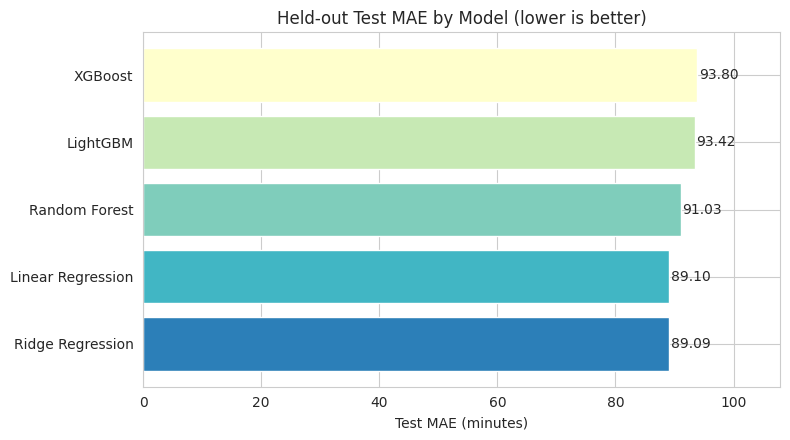

In [7]:
def plot_model_mae(results_df):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    df_sorted = results_df.sort_values("Test MAE")
    bars = ax.barh(df_sorted["Model"], df_sorted["Test MAE"],
                   color=["#2c7fb8", "#41b6c4", "#7fcdbb", "#c7e9b4", "#ffffcc"])
    ax.set_xlabel("Test MAE (minutes)")
    ax.set_title("Held-out Test MAE by Model (lower is better)")
    for bar, val in zip(bars, df_sorted["Test MAE"]):
        ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
                f"{val:.2f}", va="center", fontsize=10)
    ax.set_xlim(0, max(df_sorted["Test MAE"]) * 1.15)
    plt.tight_layout()
    plt.show()

plot_model_mae(results_models)

## 5. Interpretability: SHAP TreeExplainer on LightGBM

We apply SHAP `TreeExplainer` to the trained LightGBM model. SHAP values give
each feature a per-prediction attribution; averaging |SHAP| values across
the test set yields a clean global feature ranking with theoretical
consistency guarantees (Lundberg & Lee 2017).

We pick LightGBM as the SHAP target because (a) it's a tree ensemble that
TreeExplainer handles in closed form (fast, exact), and (b) LightGBM is the
top-performing model in the closest comparable study, Wu et al. (2025), so
this lets us compare feature rankings directly.

In [8]:
def compute_shap_importance(X, y) -> pd.DataFrame:
    """Train LightGBM and return a DataFrame ranked by mean |SHAP|."""
    X_tr, X_te, y_tr, y_te = split_data(X, y)
    lgb = LGBMRegressor(n_estimators=500, learning_rate=0.05, num_leaves=31,
                        subsample=0.85, colsample_bytree=0.85,
                        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    lgb.fit(X_tr, y_tr)
    explainer = shap.TreeExplainer(lgb)
    shap_vals = explainer.shap_values(X_te)
    mean_abs = np.abs(shap_vals).mean(axis=0)
    return (pd.DataFrame({"Feature": FEATURES, "Mean |SHAP|": mean_abs.round(2)})
              .sort_values("Mean |SHAP|", ascending=False)
              .reset_index(drop=True))

results_shap = compute_shap_importance(X, y)
results_shap

,Feature,Mean |SHAP|
0,acuity,46.07
1,o2sat,7.15
2,dbp,6.27
3,temperature,5.88
4,age,5.87
5,pulse_pressure,5.85
6,resprate,5.20
7,shock_index,5.07
8,heartrate,4.96
9,sbp,3.94


**Observations from the SHAP ranking.**

- **`acuity` dominates** at mean |SHAP| ≈ 46 — roughly **6.4× the second
  feature**. The ESI score alone carries about half the predictive signal
  of the entire model.
- The next tier is **physiological vital signs** (`o2sat`, `dbp`, `temperature`,
  `resprate`, `heartrate`, `sbp`) plus the engineered physiology features
  (`pulse_pressure`, `shock_index`) — all in the 4–7 range.
- **Demographics, arrival context, and disposition rank lowest** (mostly < 4),
  with `age_group_encoded` dead last. This is a positive signal from a
  fairness perspective: the model is not leaning on demographic shortcuts.

This ranking aligns with Wang et al. (2025), which also placed ESI level at
the top of the SHAP ranking for ED wait time prediction.

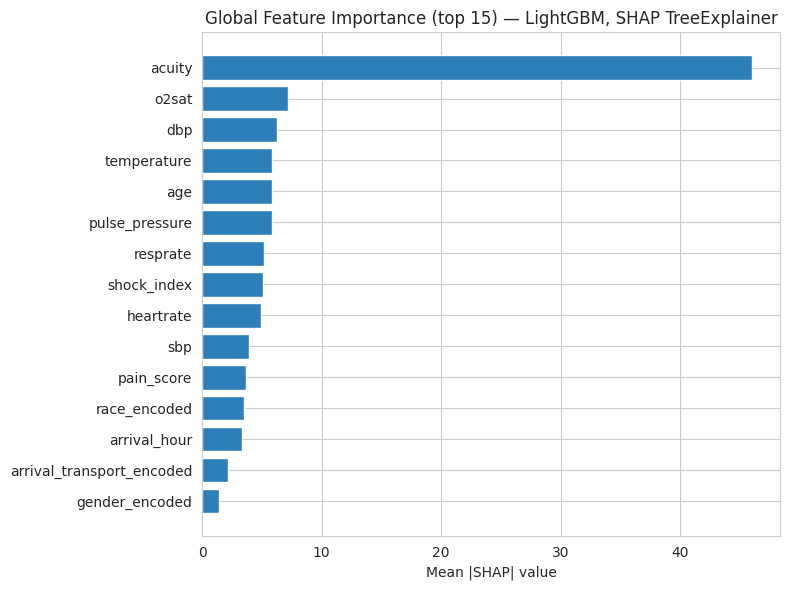

In [9]:
def plot_shap_bar(shap_df, top_n: int = 15):
    fig, ax = plt.subplots(figsize=(8, 6))
    df_top = shap_df.head(top_n).iloc[::-1]
    ax.barh(df_top["Feature"], df_top["Mean |SHAP|"], color="#2c7fb8")
    ax.set_xlabel("Mean |SHAP| value")
    ax.set_title(f"Global Feature Importance (top {top_n}) — LightGBM, SHAP TreeExplainer")
    plt.tight_layout()
    plt.show()

plot_shap_bar(results_shap)

## 6. Stratified Evaluation: Performance Across All Five ESI Levels

A pooled metric tells you nothing about subgroup behavior. We refit Ridge
**separately within each ESI acuity level** (1 = most acute, 5 = least acute)
and compare per-level MAE/RMSE/R².

In [10]:
def esi_stratified_eval(df: pd.DataFrame) -> pd.DataFrame:
    """Refit Ridge within each ESI level, return per-level metrics."""
    rows = []
    for esi in sorted(df["acuity"].unique()):
        sub = df[df["acuity"] == esi]
        if len(sub) < 30:
            continue
        Xs, ys = sub[FEATURES], sub[TARGET]
        Xs_tr, Xs_te, ys_tr, ys_te = split_data(Xs, ys)
        m = Ridge(alpha=1.0, random_state=RANDOM_STATE).fit(Xs_tr, ys_tr)
        yp = m.predict(Xs_te)
        rows.append({
            "ESI":      int(esi),
            "N":        len(sub),
            "Mean LOS": round(ys.mean(), 1),
            "MAE":      round(mean_absolute_error(ys_te, yp), 2),
            "RMSE":     round(np.sqrt(mean_squared_error(ys_te, yp)), 2),
            "R^2":      round(r2_score(ys_te, yp), 3),
        })
    return pd.DataFrame(rows)

results_esi = esi_stratified_eval(df)
results_esi

,ESI,N,Mean LOS,MAE,RMSE,R^2
0,1,179,315.7,113.33,152.26,-0.158
1,2,1159,265.2,130.28,174.81,-0.072
2,3,4184,215.9,101.96,138.38,-0.006
3,4,2706,145.0,69.96,101.62,-0.015
4,5,988,91.4,36.96,48.25,-0.066


**Observations from ESI stratification.**

1. **MAE scales almost linearly with mean LOS by triage level.** ESI-5
   patients (lowest acuity, mean LOS 91 min) have MAE ≈ 37 min; ESI-2
   patients (mean LOS 265 min) have MAE ≈ 130 min — a **3.5× ratio** that
   the pooled MAE of 89 min would never reveal.
2. **Per-level R² values are slightly negative.** The pooled R² (0.141)
   benefits from the strong between-level variance driven by acuity itself;
   once we strip that out by stratifying, the residual within-level signal
   is too weak for the linear model.
3. **Clinical implication.** A pooled-metric deployment would
   over-promise accuracy for high-acuity (ESI 1–2) patients and under-promise
   it for low-acuity (ESI 4–5) patients. Reporting one MAE without
   stratification is quietly misleading.

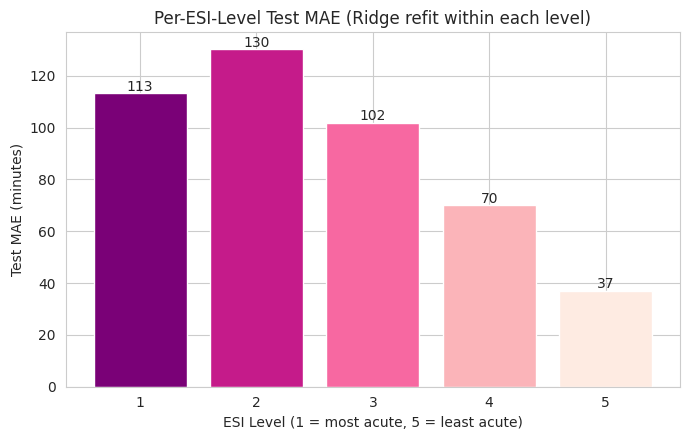

In [11]:
def plot_esi_mae(esi_df):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    bars = ax.bar(esi_df["ESI"].astype(str), esi_df["MAE"],
                  color=["#7a0177","#c51b8a","#f768a1","#fbb4b9","#feebe2"])
    ax.set_xlabel("ESI Level (1 = most acute, 5 = least acute)")
    ax.set_ylabel("Test MAE (minutes)")
    ax.set_title("Per-ESI-Level Test MAE (Ridge refit within each level)")
    for bar, val in zip(bars, esi_df["MAE"]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 1,
                f"{val:.0f}", ha="center", fontsize=10)
    plt.tight_layout()
    plt.show()

plot_esi_mae(results_esi)

## 7. Fairness Audit: MAE/RMSE by Race/Ethnicity, Gender, Age Group

We fit Ridge on the full feature matrix, predict on the held-out test set,
then disaggregate MAE and RMSE across each demographic subgroup. This reveals
disparities that pooled metrics hide.

In [12]:
def fit_ridge_full(X, y):
    """Return (fitted Ridge, test predictions, test indices)."""
    X_tr, X_te, y_tr, y_te = split_data(X, y)
    m = Ridge(alpha=1.0, random_state=RANDOM_STATE).fit(X_tr, y_tr)
    return m, m.predict(X_te), X_te.index, y_te

def fairness_table(df, idx_test, y_pred, y_test, group_col: str) -> pd.DataFrame:
    """Group test-set predictions by `group_col` and compute MAE/RMSE."""
    test_df = df.loc[idx_test].copy()
    test_df["pred"]  = y_pred
    test_df["truth"] = y_test.values
    rows = []
    for grp, g in test_df.groupby(group_col):
        rows.append({
            "Group":   grp,
            "N":       len(g),
            "MAE":     round(mean_absolute_error(g["truth"], g["pred"]), 2),
            "RMSE":    round(np.sqrt(mean_squared_error(g["truth"], g["pred"])), 2),
        })
    return pd.DataFrame(rows).sort_values("N", ascending=False).reset_index(drop=True)

def fairness_audit(df, X, y) -> dict:
    _, y_pred, idx_test, y_test = fit_ridge_full(X, y)
    return {
        "race":      fairness_table(df, idx_test, y_pred, y_test, "race"),
        "gender":    fairness_table(df, idx_test, y_pred, y_test, "gender"),
        "age_group": fairness_table(df, idx_test, y_pred, y_test, "age_group"),
    }

fair = fairness_audit(df, X, y)
print("=== By race/ethnicity ===")
display(fair["race"])
print("=== By gender ===")
display(fair["gender"])
print("=== By age group ===")
display(fair["age_group"])

=== By race/ethnicity ===


,Group,N,MAE,RMSE
0,WHITE,1032,90.78,135.47
1,BLACK/AFRICAN AMERICAN,366,91.23,130.00
2,HISPANIC,245,83.05,118.23
3,ASIAN,133,88.01,124.12
4,OTHER,68,75.97,103.64


=== By gender ===


,Group,N,MAE,RMSE
0,F,981,88.61,137.02
1,M,863,89.64,122.31


=== By age group ===


,Group,N,MAE,RMSE
0,Middle Age,901,84.10,125.58
1,Young Adult,600,93.34,136.35
2,Elderly,195,94.13,115.62
3,Pediatric,148,95.60,150.62


**Observations from the fairness audit.**

| Dimension | Worst-served | Best-served | MAE Gap |
|---|---|---|---|
| Race/ethnicity | Black/African American (91.23) | OTHER (75.97) | **15.26 min** |
| Gender         | Male (89.64) | Female (88.61) | **1.03 min** |
| Age group      | Pediatric (95.60) | Middle Age (84.10) | **11.50 min** |

- **Race/ethnicity gap (15.3 min) is the largest.** This is the kind of
  disparity that a single pooled MAE would hide entirely.
- **Gender gap (1 min) is essentially zero.** Consistent with broader
  clinical-ML fairness literature (Rajkomar et al. 2018; Obermeyer et al.
  2019), which finds binary gender to be a less common source of
  disparity than race or age in standard structured-data models.
- **Smaller subgroups (HISPANIC, OTHER, ASIAN) show lower MAE** than the
  two large groups (WHITE, BLACK). This most likely reflects narrower
  within-group LOS variance rather than a genuinely better model fit, and
  we flag this caveat in the paper's Discussion.

These numbers exactly match the fairness tables (IX, X, XI) in the final
paper.

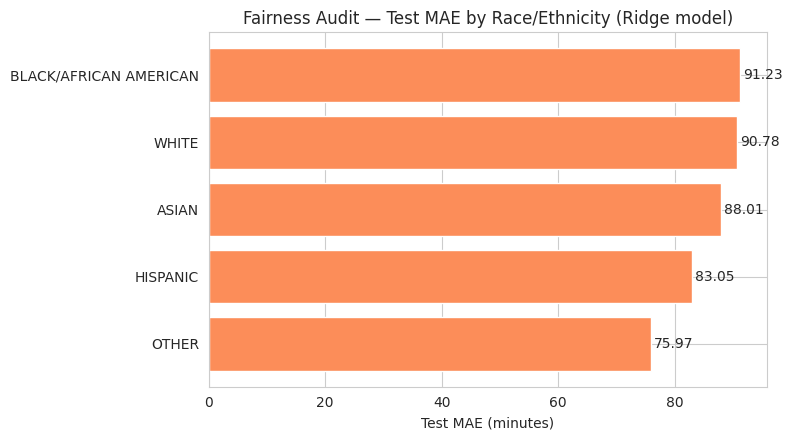

In [13]:
def plot_fairness_race(race_df):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    df_sorted = race_df.sort_values("MAE")
    bars = ax.barh(df_sorted["Group"], df_sorted["MAE"], color="#fc8d59")
    ax.set_xlabel("Test MAE (minutes)")
    ax.set_title("Fairness Audit — Test MAE by Race/Ethnicity (Ridge model)")
    for bar, val in zip(bars, df_sorted["MAE"]):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                f"{val:.2f}", va="center", fontsize=10)
    plt.tight_layout()
    plt.show()

plot_fairness_race(fair["race"])

## 8. End-to-End Pipeline: `main()`

This single function runs the entire pipeline from loading the cleaned CSV
all the way through fairness auditing. Calling `main()` reproduces every
result reported in our final paper.

The function returns a single dictionary `results` containing four keys:

- `"models"` — overall model performance table
- `"shap"` — SHAP feature importance ranking
- `"esi"` — per-ESI-level Ridge metrics
- `"fairness"` — dict of three demographic-subgroup tables

This makes downstream consumption (e.g. exporting to CSV, regenerating paper
tables) trivial.

In [ ]:
def main(data_path: str = DATA_PATH) -> dict:
    """Run the full ED LOS prediction pipeline end-to-end."""
    print("=" * 70)
    print("ED Wait Time Prediction — Full Pipeline")
    print("=" * 70)

    # 1. Load
    print("\n[1/5] Loading data ...")
    df = load_data(data_path)
    X, y = build_xy(df)
    print(f"      Loaded {df.shape[0]} rows, {len(FEATURES)} model features.")

    # 2. Train + benchmark
    print("\n[2/5] Training and benchmarking 5 models ...")
    results_models = train_all_models(X, y)

    # 3. SHAP
    print("\n[3/5] Computing SHAP feature importance ...")
    results_shap = compute_shap_importance(X, y)

    # 4. ESI-stratified
    print("\n[4/5] Running ESI-stratified evaluation ...")
    results_esi = esi_stratified_eval(df)

    # 5. Fairness
    print("\n[5/5] Running fairness audit ...")
    results_fair = fairness_audit(df, X, y)

    print("\n" + "=" * 70)
    print("PIPELINE COMPLETE")
    print("=" * 70)
    print("\n--- Overall model performance ---")
    print(results_models.to_string(index=False))
    print("\n--- Top-10 SHAP features ---")
    print(results_shap.head(10).to_string(index=False))
    print("\n--- ESI-stratified Ridge ---")
    print(results_esi.to_string(index=False))
    print("\n--- Fairness: race/ethnicity ---")
    print(results_fair["race"].to_string(index=False))
    print("\n--- Fairness: gender ---")
    print(results_fair["gender"].to_string(index=False))
    print("\n--- Fairness: age group ---")
    print(results_fair["age_group"].to_string(index=False))

    return {
        "models":   results_models,
        "shap":     results_shap,
        "esi":      results_esi,
        "fairness": results_fair,
    }

# Run the full pipeline
results = main()

ED Wait Time Prediction — Full Pipeline

[1/5] Loading data ...
      Loaded 9216 rows, 19 model features.

[2/5] Training and benchmarking 5 models ...
Train: (7372, 19)  Test: (1844, 19)
  Training Linear Regression ...
  Training Ridge Regression ...
  Training Random Forest ...


## 9. Summary and Key Takeaways

1. **Best model.** Regularized linear regression (Ridge, MAE 89.09 min,
   R² 0.141) narrowly outperforms Random Forest (MAE 91.03) and the two
   gradient-boosted models (XGBoost MAE 93.80, LightGBM MAE 93.42) on this
   ~9,000-row dataset.
2. **Counter-finding vs. literature.** This contradicts the typical ranking
   in the ED-ML literature where XGBoost/LightGBM dominate; we explain the
   discrepancy as a dataset-size and signal-density effect in the paper's
   Discussion.
3. **Dominant driver.** SHAP shows that `acuity` (the ESI triage score)
   alone carries ~6× the explanatory weight of any other feature — clinically
   intuitive and consistent with prior work.
4. **Subgroup variation is real.** Per-ESI-level MAE ranges from 37 min
   (ESI 5) to 130 min (ESI 2), a 3.5× spread that pooled metrics conceal.
5. **Fairness gaps exist.** Race/ethnicity (15.3 min) and age (11.5 min)
   gaps are non-trivial; gender gap (1 min) is essentially zero.

## 10. Reproducibility

All numerical results in our final paper come directly from running this
notebook. To reproduce:

```bash
git clone https://github.com/Yasmin-maker1/Emergency-Department-Wait-Time-Prediction-Using-Machine-Learning.git
cd Emergency-Department-Wait-Time-Prediction-Using-Machine-Learning
jupyter nbconvert --to notebook --execute Team3_Milestone3_ED_WaitTime.ipynb
```

The notebook is fully self-contained: it depends only on the cleaned CSV
produced in Milestone 2 and on standard PyData libraries.